In [12]:
import os 
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from matplotlib import pyplot as plt
from transformers import BertTokenizer, BertModel, BertForSequenceClassification
from datasets import load_dataset

# Introduction

In this notebook, we will go through:
- Visualizing Attention in Transformers

## On a simple example

Load a pre-trained BertModel and BertTokenizer from the Hugging Face Transformers library.

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

Explore the BertModel's structure and its parameters. Can you find the attention layers and the dimensions of the matrices as we defined in the lesson ?

In [ ]:
# Get the model's encoder structure
encoder = model.encoder
print(encoder)

BertEncoder(
  (layer): ModuleList(
    (0-11): 12 x BertLayer(
      (attention): BertAttention(
        (self): BertSelfAttention(
          (query): Linear(in_features=768, out_features=768, bias=True)
          (key): Linear(in_features=768, out_features=768, bias=True)
          (value): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (output): BertSelfOutput(
          (dense): Linear(in_features=768, out_features=768, bias=True)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
      (intermediate): BertIntermediate(
        (dense): Linear(in_features=768, out_features=3072, bias=True)
        (intermediate_act_fn): GELUActivation()
      )
      (output): BertOutput(
        (dense): Linear(in_features=3072, out_features=768, bias=True)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)

In [160]:
# Get the model's embedding layer
embedding = model.embeddings
print(embedding)

BertEmbeddings(
  (word_embeddings): Embedding(30522, 768, padding_idx=0)
  (position_embeddings): Embedding(512, 768)
  (token_type_embeddings): Embedding(2, 768)
  (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
)


In [161]:
# Get the model's first MHA layer
attention = model.encoder.layer[0].attention
print(attention)

BertAttention(
  (self): BertSelfAttention(
    (query): Linear(in_features=768, out_features=768, bias=True)
    (key): Linear(in_features=768, out_features=768, bias=True)
    (value): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (output): BertSelfOutput(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)


Now we will run inference on a simple text sentence. Use the tokenizer item to convert the text into tokens, and then use the model item to get the hidden states and attention scores.

In [ ]:
text = "the animal didn't cross the street because it was too tired"

inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True)
outputs = model(**inputs, output_attentions=True, output_hidden_states=True)

Now get the attention score of the 5th layer of the model. How many heads do you have ? What is the shape of the attention matrix ? Find a method to get a NxN matrix where N is the number of tokens in the sentence, so that we can visualise the attention.

The BertModel takes as input a sequence that starts with a special token [CLS] and ends with a special token [SEP]. The attention matrix will have the shape (N+2)x(N+2) where N is the number of tokens in the sentence. Don't forget to remove the special tokens before visualizing the attention.

To visualize with a pretty heatmap, you can use the matshow method from matplotlib. You can also add the tokens on the x and y axes to see which token attends to which token.

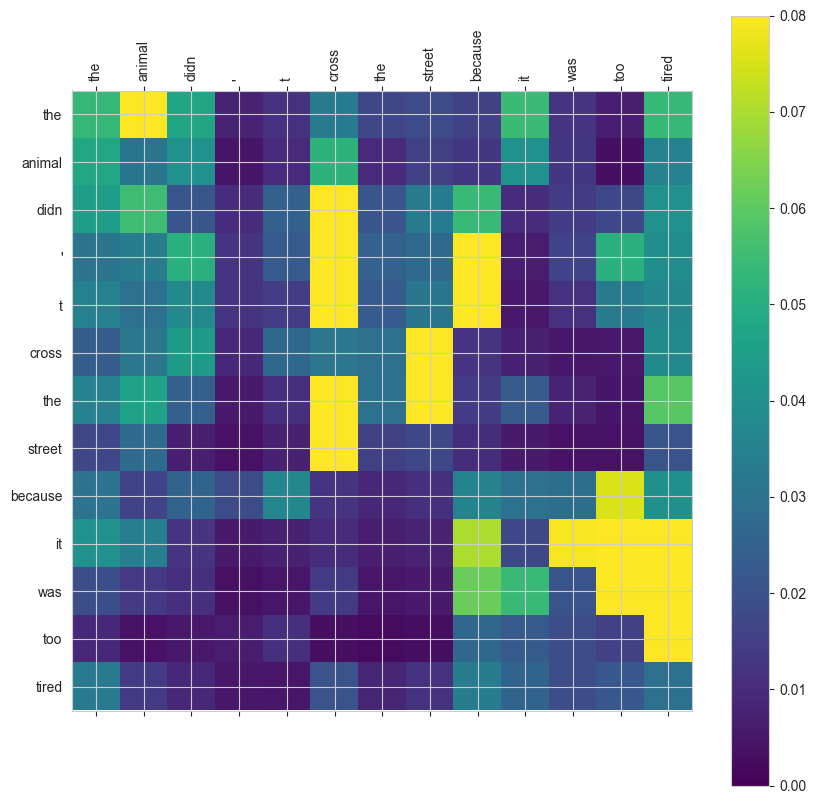

In [163]:
layers = [attention[0] for attention in outputs.attentions]
attention = layers[5]

# Average the values over all heads 
attention = attention.mean(dim=0)
attention = attention.detach().numpy()
attention = attention[1:-1, 1:-1] # Ignore the special tokens

# Visualize attention
tokenized_text = tokenizer.tokenize(text)

fig, ax = plt.subplots(figsize=(10,10))
cax = ax.matshow(attention, cmap='viridis', vmin=0, vmax=0.08)
fig.colorbar(cax)

# Set up axes
ax.set_xticks(np.arange(attention.shape[1]), minor=False)
ax.set_yticks(np.arange(attention.shape[0]), minor=False)
ax.set_xticklabels(tokenized_text, rotation=90, fontsize=10)
ax.set_yticklabels(tokenized_text, fontsize=10)
plt.show()

## Example on a real dataset
## Importing the data

In [164]:
# Load the dataset
dataset = load_dataset("imdb")

## 1. Visualize the data, and play with it to get familiar



In [165]:
# Get a random example
example = dataset['train'][110]

# Print the example
print(example)

# see how the data is structured (keys, values, etc.)
print(example.keys())


{'text': "Nine minutes of psychedelic, pulsating, often symmetric abstract images, are enough to drive anyone crazy. I did spot a full-frame eye at the start, and later some birds silhouetted against other colors. It was just not my cup of tea. It's about 8½ minutes too long.", 'label': 0}
dict_keys(['text', 'label'])


## 2. Import a BertForSequenceClassification model from the Hugging Face Transformers library.

In [176]:
# Import a model that has already been trained on the IMDB dataset. 
# model = BertForSequenceClassification.from_pretrained('lvwerra/bert-imdb')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased')
# Import a tokenizer that will convert the text into tokens that the model can understand
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 3. Run inference on the example

In [ ]:
# Tokenize the input
inputs = tokenizer(example['text'], return_tensors='pt', padding=True, truncation=True)

# Run the model
outputs = model(**inputs, output_attentions=True, output_hidden_states=True)
print(f'Logits: {outputs.logits}')
print(f'Prediction scores: {F.softmax(outputs.logits)}')
# Get the predicted class
predicted_class = torch.argmax(F.softmax(outputs.logits), dim=1).item()

print(f'Predicted class: {predicted_class}')


Logits: tensor([[-0.5726,  0.5397]], grad_fn=<AddmmBackward0>)
Prediction scores: tensor([[0.2474, 0.7526]], grad_fn=<SoftmaxBackward0>)
Predicted class: 1


/var/folders/db/zhj9gnf900d35lzmsy2drjhh0000gn/T/ipykernel_39027/219420065.py:8: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  print(f'Prediction scores: {F.softmax(outputs.logits)}')
/var/folders/db/zhj9gnf900d35lzmsy2drjhh0000gn/T/ipykernel_39027/219420065.py:10: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  predicted_class = torch.argmax(F.softmax(outputs.logits), dim=1).item()


## 4. Get the attention scores (QK^T) from the model. Get it from the last head of the last layer.

In [178]:
# Get the attention scores from the model
attentions = outputs.attentions
print(len(attentions)) # We have 12 layers
print(attentions[-1].shape) # The last layer has 12 heads, and the sequence length here is 206

attention_scores = attentions[-1][0] # Get the attention scores for the last layer
print(attention_scores.shape)
attention_scores_last_head = attention_scores[-1] # Get the attention scores for the last head
print(attention_scores_last_head.shape) # Now we have the attention scores for the last head of the last layer

print(attention_scores_last_head)
attention_scores_last_head = attention_scores_last_head.detach().numpy()


12
torch.Size([1, 12, 64, 64])
torch.Size([12, 64, 64])
torch.Size([64, 64])
tensor([[3.9562e-03, 6.7165e-03, 1.1372e-02,  ..., 3.0822e-03, 1.5115e-02,
         4.1064e-02],
        [3.6410e-04, 2.1117e-03, 3.4683e-03,  ..., 2.9957e-04, 5.4526e-05,
         6.4259e-04],
        [2.8782e-03, 1.8153e-03, 2.3680e-02,  ..., 7.6812e-04, 1.7065e-04,
         7.8625e-03],
        ...,
        [7.9590e-03, 6.7746e-03, 2.5799e-02,  ..., 3.5682e-03, 7.3405e-04,
         8.0910e-03],
        [2.5380e-03, 7.8228e-04, 7.2380e-04,  ..., 1.4493e-04, 4.8323e-04,
         1.1439e-03],
        [6.2555e-03, 5.0624e-03, 6.5967e-03,  ..., 1.2139e-03, 2.5126e-03,
         1.5041e-02]], grad_fn=<SelectBackward0>)


## 5. Visualize the attention heatmap on this text.

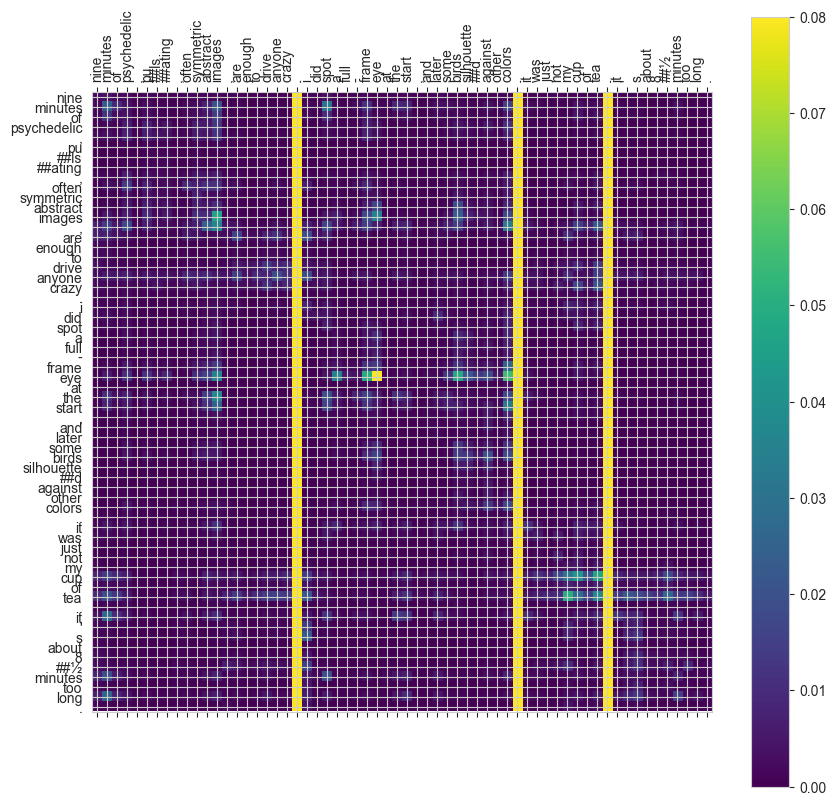

In [179]:
attention = attention_scores_last_head[1:-1, 1:-1] # Ignore the special tokens

# Visualize attention
tokenized_text = tokenizer.tokenize(example['text'])

fig, ax = plt.subplots(figsize=(10,10))
cax = ax.matshow(attention, cmap='viridis', vmin=0, vmax=0.08)
fig.colorbar(cax)

# Set up axes
ax.set_xticks(np.arange(attention.shape[1]), minor=False)
ax.set_yticks(np.arange(attention.shape[0]), minor=False)
ax.set_xticklabels(tokenized_text, rotation=90, fontsize=10)
ax.set_yticklabels(tokenized_text, fontsize=10)
plt.show()